# Problem Statement:

The data scientists at BigMart have collected 2013 sales data for 1559 products across 10 stores in different cities. Also, certain attributes of each product and store have been defined. The aim is to build a predictive model and find out the sales of each product at a particular store.

Using this model, BigMart will try to understand the properties of products and stores which play a key role in increasing the sales of their products.

The dataset includes two files:

- bigdatamart_Train.csv: Use this file for the model building purpose. 

- bigdatamart_Test.csv: Use this file for getting predictions from the trained model. 

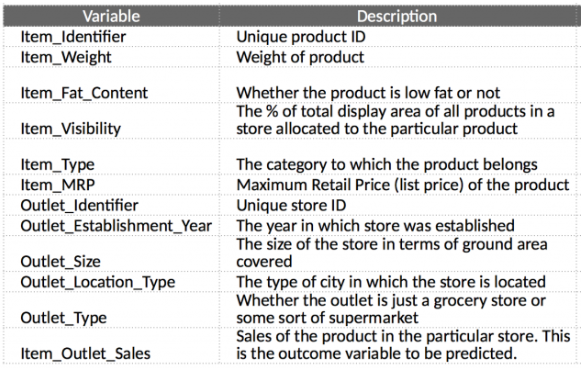

### We have two different data set for training and testing model. So we will at first statisically explore and clean these dataset individually. After that we will perfom EDA on training data. Once we done with EDA, next thing is feature engineering and selection Separately on train & test dataset. At last we will go for model building on training dataset and testing on test dataset with various ML algorithim. Crossvalidation and evalution matrix will employ sepeartely before deciding final model.

## Importing Train and Test csv file

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
train=pd.read_csv('bigdatamart_Train.csv')

# Statistical Anaysis, Data Exploration & Cleaning on Train Dataset

In [3]:
train.head(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


#### Comment -
1. Train data contain 8523 rows with 11 features and 1 target variable.
2. Some feature are categorical in nature.
3. There is presense of Null values in data.
4. There is missing data in item weight, outlet size which need to impute with appropriate method.

In [5]:
train.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


## Indentification of Missing Data

In [6]:
train.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

#### Comment -
1. 28.27% missing data in Outlet size
2. 17.16% missing data in Item weight.
3. Outlet which are very big in size normally have every varity of product avaiable at single place, massive customer footprint and in turn have higher sales. Outlet size is important feature in our analysis. hence we cannot just ignore missing data here.
4. Tier 2 & 3 cities tend to have customer who do not store grocery in big number. Item weight is critical for them. Like Outlet size here also we cannot just ignore missing values.

## Indentifying Unique categories for categorical data

### 1.Item_Fat_Content

In [7]:
train['Item_Fat_Content'].unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

<Axes: xlabel='Item_Fat_Content', ylabel='count'>

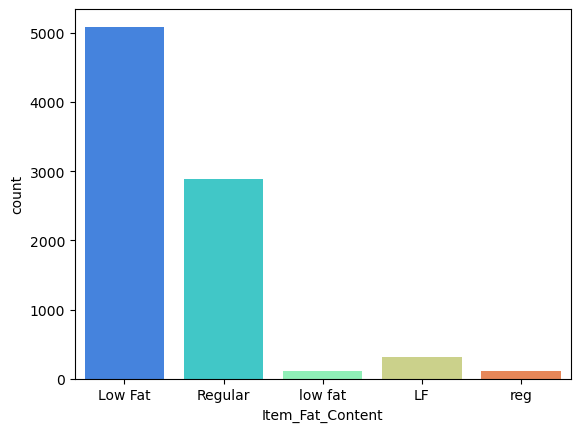

In [8]:
sns.countplot(x=train['Item_Fat_Content'], palette='rainbow')

Some of ‘Low Fat’ values mis-coded as ‘low fat’ and ‘LF’. Also, some of ‘Regular’ are mentioned as ‘reg’. 

We are going to convert them into two catgories - 1. Low Fat  2.Regular

In [9]:
train['Item_Fat_Content']=train['Item_Fat_Content'].replace('LF','Low Fat')
train['Item_Fat_Content']=train['Item_Fat_Content'].replace('low fat','Low Fat')
train['Item_Fat_Content']=train['Item_Fat_Content'].replace('reg','Regular')

In [10]:
#train['Item_Fat_Content']=train['Item_Fat_Content'].replace({'LF':'Low Fat','low fat':'Low Fat','reg':'Regular'})

In [11]:
train['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

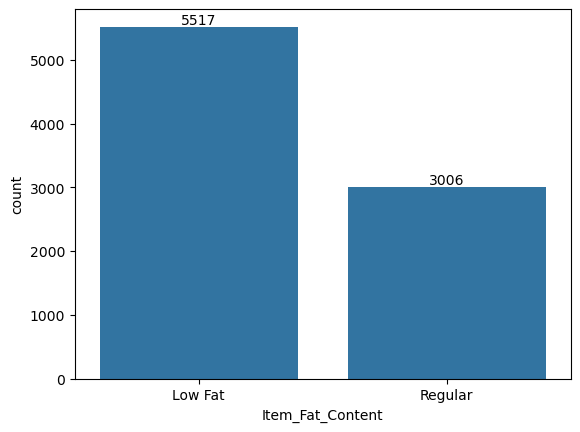

In [12]:
label=sns.countplot(x="Item_Fat_Content",data=train)
for i in label.containers:
    label.bar_label(i)

<Axes: ylabel='count'>

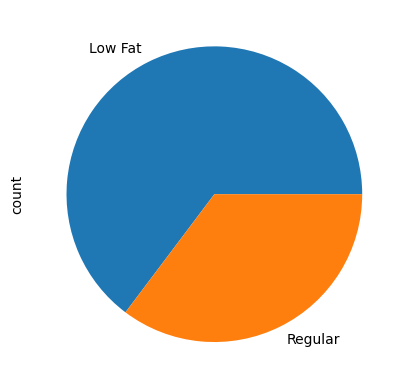

In [13]:
train["Item_Fat_Content"].value_counts().plot(kind="pie")

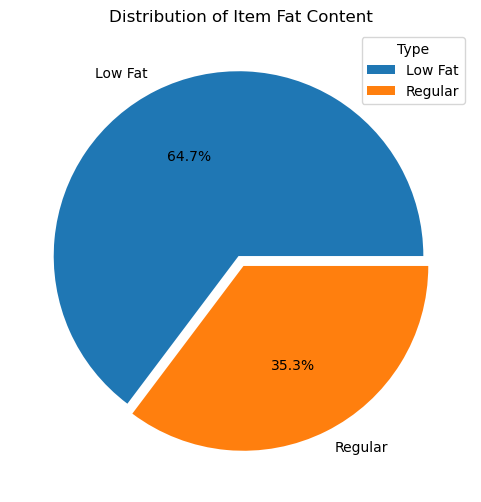

In [14]:
# Create pie chart
plt.figure(figsize=(6, 6))
plt.pie(train["Item_Fat_Content"].value_counts().values, 
      labels=train["Item_Fat_Content"].value_counts().index, autopct='%1.1f%%',explode=[0.03,0.03])
plt.title('Distribution of Item Fat Content')
plt.legend(title="Type", loc='upper right')  # Adding legend in the upper-right corner
plt.show()

In [15]:
train['Item_Type'].value_counts()

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

In [16]:
train['Item_Type'].unique()

array(['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables',
       'Household', 'Baking Goods', 'Snack Foods', 'Frozen Foods',
       'Breakfast', 'Health and Hygiene', 'Hard Drinks', 'Canned',
       'Breads', 'Starchy Foods', 'Others', 'Seafood'], dtype=object)

### 2. Item_Type & Item_Identifier

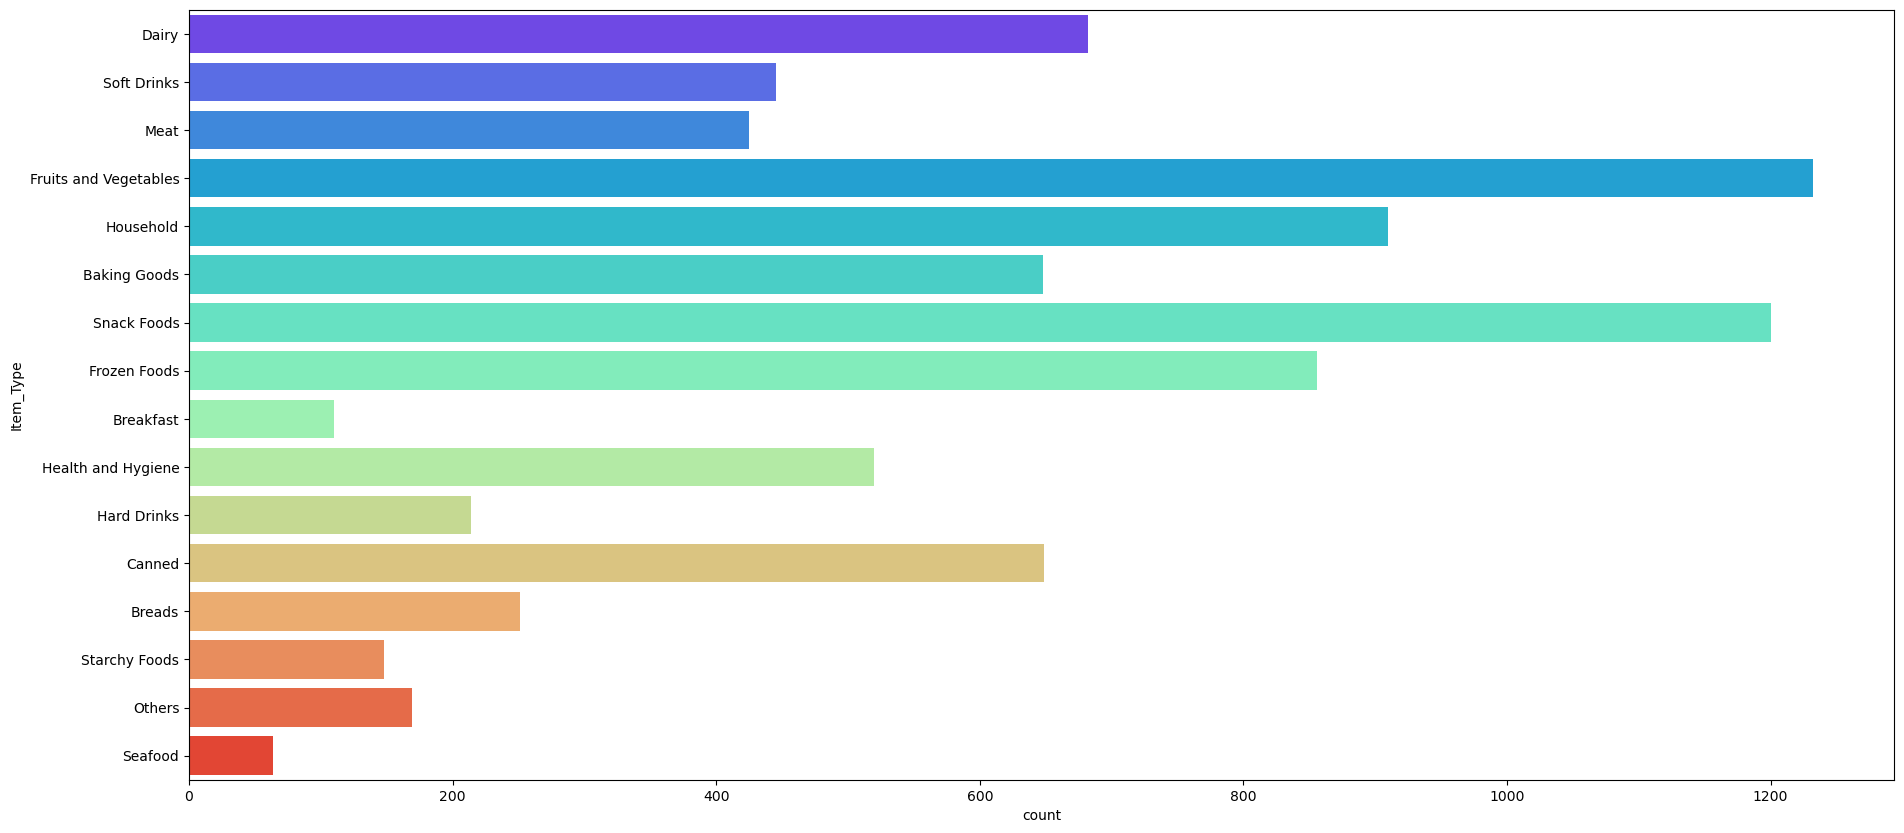

In [17]:
plt.figure(figsize=(22,10))
sns.countplot(y=train['Item_Type'], palette='rainbow')
plt.show()

In [18]:
train['Item_Type'].value_counts()

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

In [19]:
train['Item_Type'].nunique()

16

There are 1599 products within 16 different item categories in Big Data Mart store.

In [20]:
train['Item_Identifier'].unique()

array(['FDA15', 'DRC01', 'FDN15', ..., 'NCF55', 'NCW30', 'NCW05'],
      dtype=object)

In [21]:
x=['FDA15', 'DRC01','NCW30']
y=[]
for i in x:
    y.append(i[:2])
y

['FD', 'DR', 'NC']

##### If you look at the Item_Identifier, i.e. the unique ID of each item, it starts with either FD, DR or NC. If you see the categories, these look like being Food, Drinks and Non-Consumables.So I’ve used the Item_Identifier variable to create a new column to simplify further analysis.

In [22]:
#Item type combine:
train['Item_Type_Combined'] = train['Item_Identifier'].apply(lambda x: x[:2])
train['Item_Type_Combined'].unique()

train['Item_Type_Combined'] = train['Item_Type_Combined'].map({'FD':'Food',
                                                             'NC':'Non-Consumable',
                                                             'DR':'Drinks'})
train['Item_Type_Combined'].value_counts()

Item_Type_Combined
Food              6125
Non-Consumable    1599
Drinks             799
Name: count, dtype: int64

##### A fat-content should not be specified for Non-consumables them. So I created a new category as Non-Edible for such Nonconsumable under Item Fat Content Column.

In [23]:
train.loc[train['Item_Type_Combined']=='Non-Consumable','Item_Fat_Content']='Non-Edible'
train['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat       3918
Regular       3006
Non-Edible    1599
Name: count, dtype: int64

In [24]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
 12  Item_Type_Combined         8523 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage:

### 3.Outlet_Identifier

<Axes: xlabel='Outlet_Identifier', ylabel='count'>

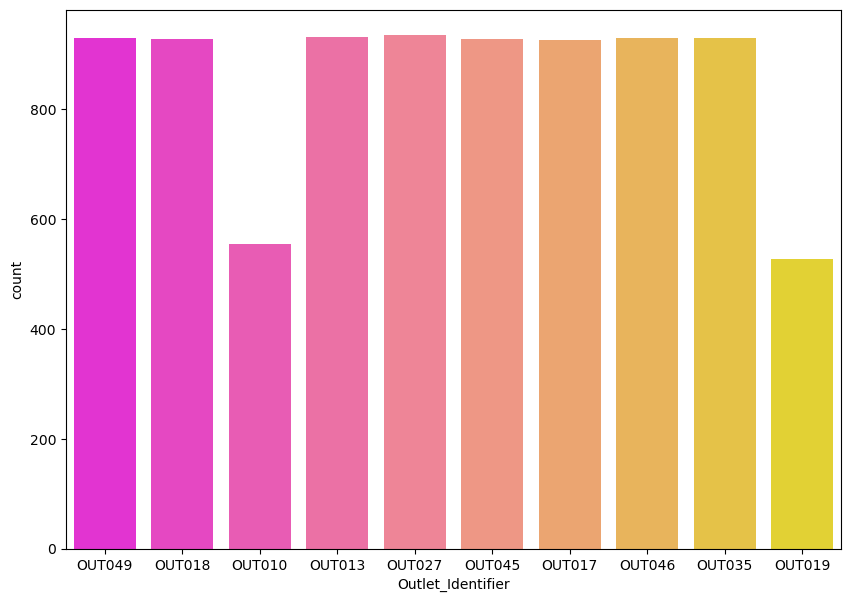

In [25]:
plt.figure(figsize=(10,7))
sns.countplot(x=train['Outlet_Identifier'], palette='spring')

### 4.Outlet_Type 

In [26]:
train['Outlet_Type'].value_counts()

Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: count, dtype: int64

<Axes: xlabel='Outlet_Type', ylabel='count'>

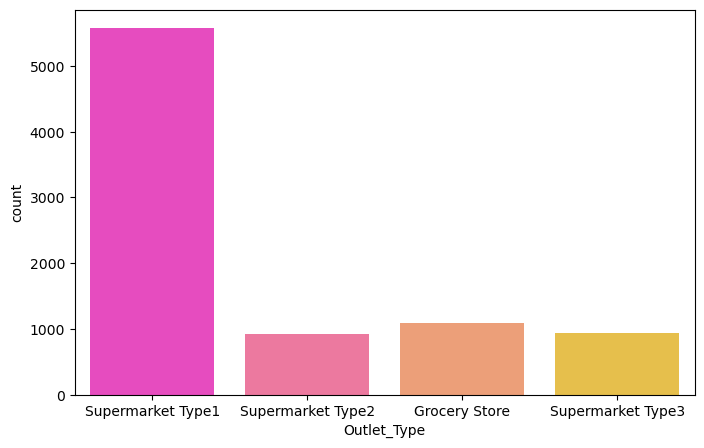

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(x=train['Outlet_Type'], palette='spring')

In [28]:
#Check the mean sales by type:
train.pivot_table(values='Item_Outlet_Sales', index='Outlet_Type')

,Item_Outlet_Sales
Outlet_Type,
Grocery Store,339.828500
Supermarket Type1,2316.181148
Supermarket Type2,1995.498739
Supermarket Type3,3694.038558


In [29]:
train.groupby("Outlet_Type")["Item_Outlet_Sales"].mean()

Outlet_Type
Grocery Store         339.828500
Supermarket Type1    2316.181148
Supermarket Type2    1995.498739
Supermarket Type3    3694.038558
Name: Item_Outlet_Sales, dtype: float64

### 5.Outlet_Location_Type

In [30]:
train['Outlet_Location_Type'].value_counts()

Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64

<Axes: xlabel='Outlet_Location_Type', ylabel='count'>

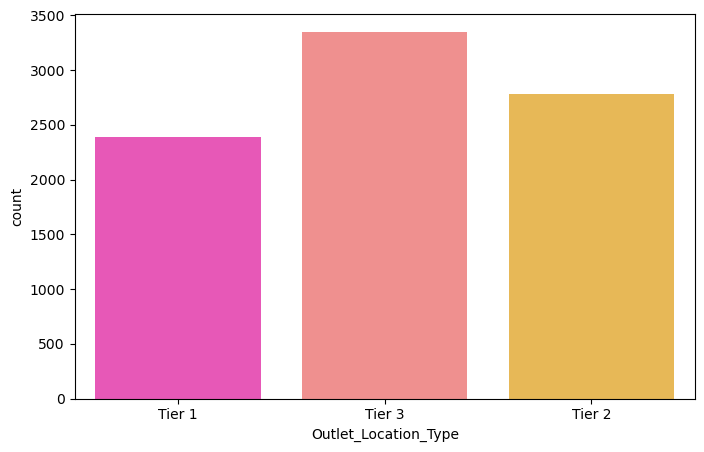

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(x=train['Outlet_Location_Type'], palette='spring')

In [32]:
#Check the mean sales by type:
train.pivot_table(values='Item_Outlet_Sales', index='Outlet_Location_Type')

,Item_Outlet_Sales
Outlet_Location_Type,
Tier 1,1876.909159
Tier 2,2323.990559
Tier 3,2279.627651


#### Comment -
1. Maximum Number of Outlet are in Tier 3 Cities and they Genearte maximum revenue as compare to Tier 1 & Tier 2.

## Handling Missing Values

### 1. Imputation of Item Weight

In [33]:
train['Item_Weight'].isnull().sum()

np.int64(1463)

In [34]:
train['Item_Weight'] = train.groupby('Item_Type')['Item_Weight'].transform(lambda x: x.fillna(x.mean()))

In [35]:
train['Item_Weight'].isnull().sum()

np.int64(0)

##### Lets impute the Item Weight by the average weight of the particular item as per Item_Identifier

In [36]:
train.head(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Type_Combined
0,FDA15,9.30000,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,Food
1,DRC01,5.92000,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,Drinks
2,FDN15,17.50000,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,Food
3,FDX07,19.20000,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800,Food
4,NCD19,8.93000,Non-Edible,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,Non-Consumable
5,FDP36,10.39500,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088,Food
6,FDO10,13.65000,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528,Food
7,FDP10,12.98788,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636,Food
8,FDH17,16.20000,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986,Food
9,FDU28,19.20000,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350,Food


In [37]:
mean_item_weight=train.groupby('Item_Type').agg({'Item_Weight':'mean'})
mean_item_weight

,Item_Weight
Item_Type,
Baking Goods,12.277108
Breads,11.346936
Breakfast,12.768202
Canned,12.305705
Dairy,13.426069
Frozen Foods,12.867061
Fruits and Vegetables,13.224769
Hard Drinks,11.400328
Health and Hygiene,13.142314


### 2. Imputation of Outlet Size

In [38]:
train['Outlet_Size'].value_counts()

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

In [39]:
train['Outlet_Size'].isna().sum()

np.int64(2410)

<Axes: xlabel='Outlet_Size', ylabel='count'>

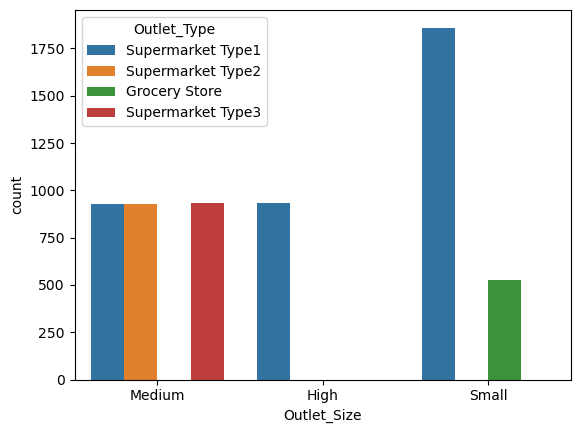

In [40]:
sns.countplot(x='Outlet_Size',hue='Outlet_Type',data=train)

In [41]:
train["Outlet_Size"].fillna("unknown",inplace=True)

##### Missing Values table after imputation

## Exploration of Train Numerical data

### Item_Visibility

The min value of Item_Visibility is 0, but this can not be as every item which sold over store must have some visibility.

In [42]:
train[train['Item_Visibility']==0]['Item_Identifier'].nunique()

446

In [43]:
# visual check that the 0 values in the firs 10 entries have been replaced
train['Item_Visibility']=train['Item_Visibility'].replace(0,np.nan)

In [44]:
train['Item_Visibility'].fillna(train['Item_Visibility'].median(),inplace=True)

In [45]:
train[train['Item_Visibility']==0]['Item_Identifier'].nunique()

0

### Outlet_Establishment_Year

<Axes: xlabel='Outlet_Establishment_Year', ylabel='count'>

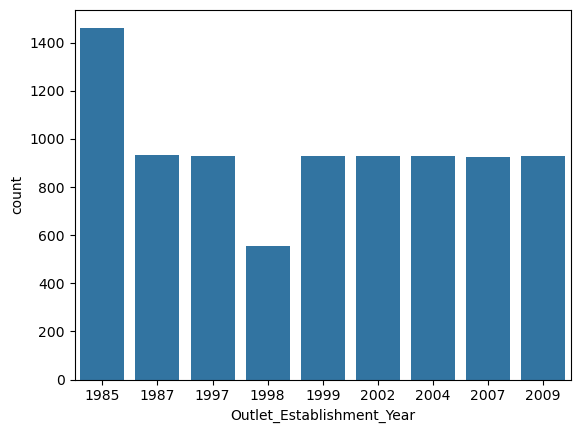

In [46]:
sns.countplot(x=train["Outlet_Establishment_Year"])

In [47]:
train['Outlet_Age'] = train['Outlet_Establishment_Year'].apply(lambda x:2013-x)

In [48]:
train['Outlet_Age'].head()

0    14
1     4
2    14
3    15
4    26
Name: Outlet_Age, dtype: int64

---------------------------------------------------------------------------------------------------------------------------

##### Missing Values table after imputation

In [49]:
train.shape

(8523, 14)

In [50]:
numerical=train.select_dtypes(exclude="object")
numerical.shape


(8523, 6)

In [51]:
#df=train.drop(columns=['Item_Identifier','Item_Fat_Content','Item_Type','Outlet_Identifier','Outlet_Size','Outlet_Location_Type','Outlet_Type','Item_Type_Combined'])

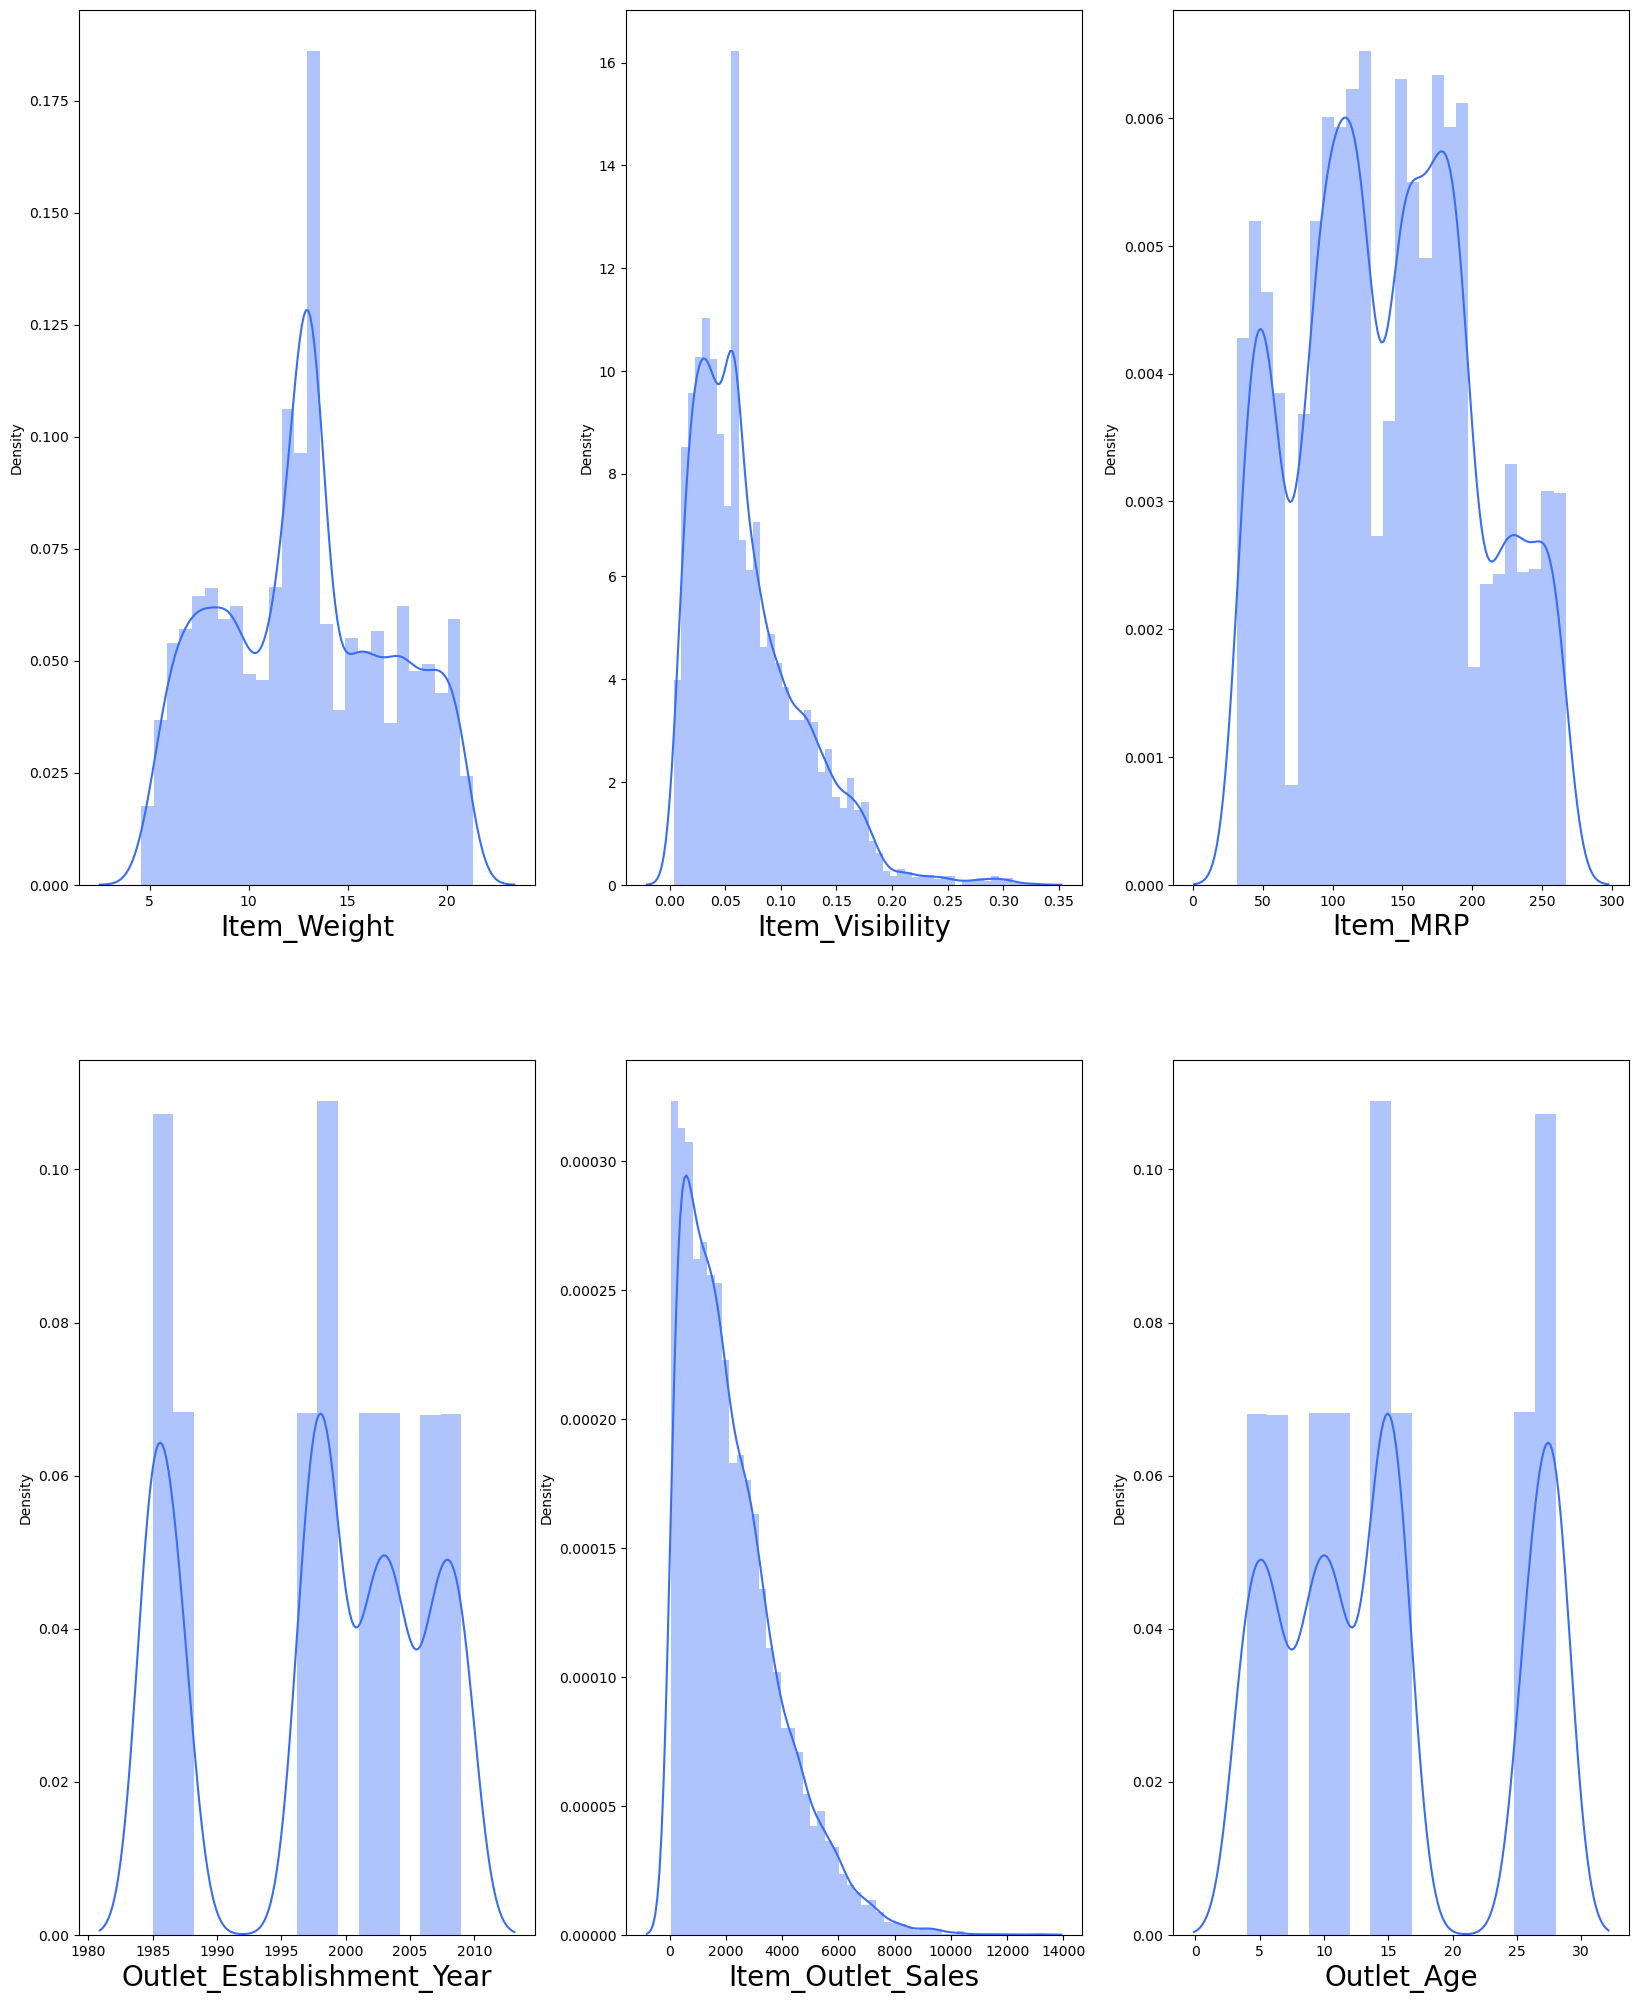

In [52]:
plt.figure(figsize=(20,25), facecolor='white')
sns.set_palette('rainbow')
plotnumber =1
for column in numerical:
    if plotnumber <=6:
        ax = plt.subplot(2,3,plotnumber)
        sns.distplot(train[column])
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.show()

#### Box plot for outliers detection in Training data

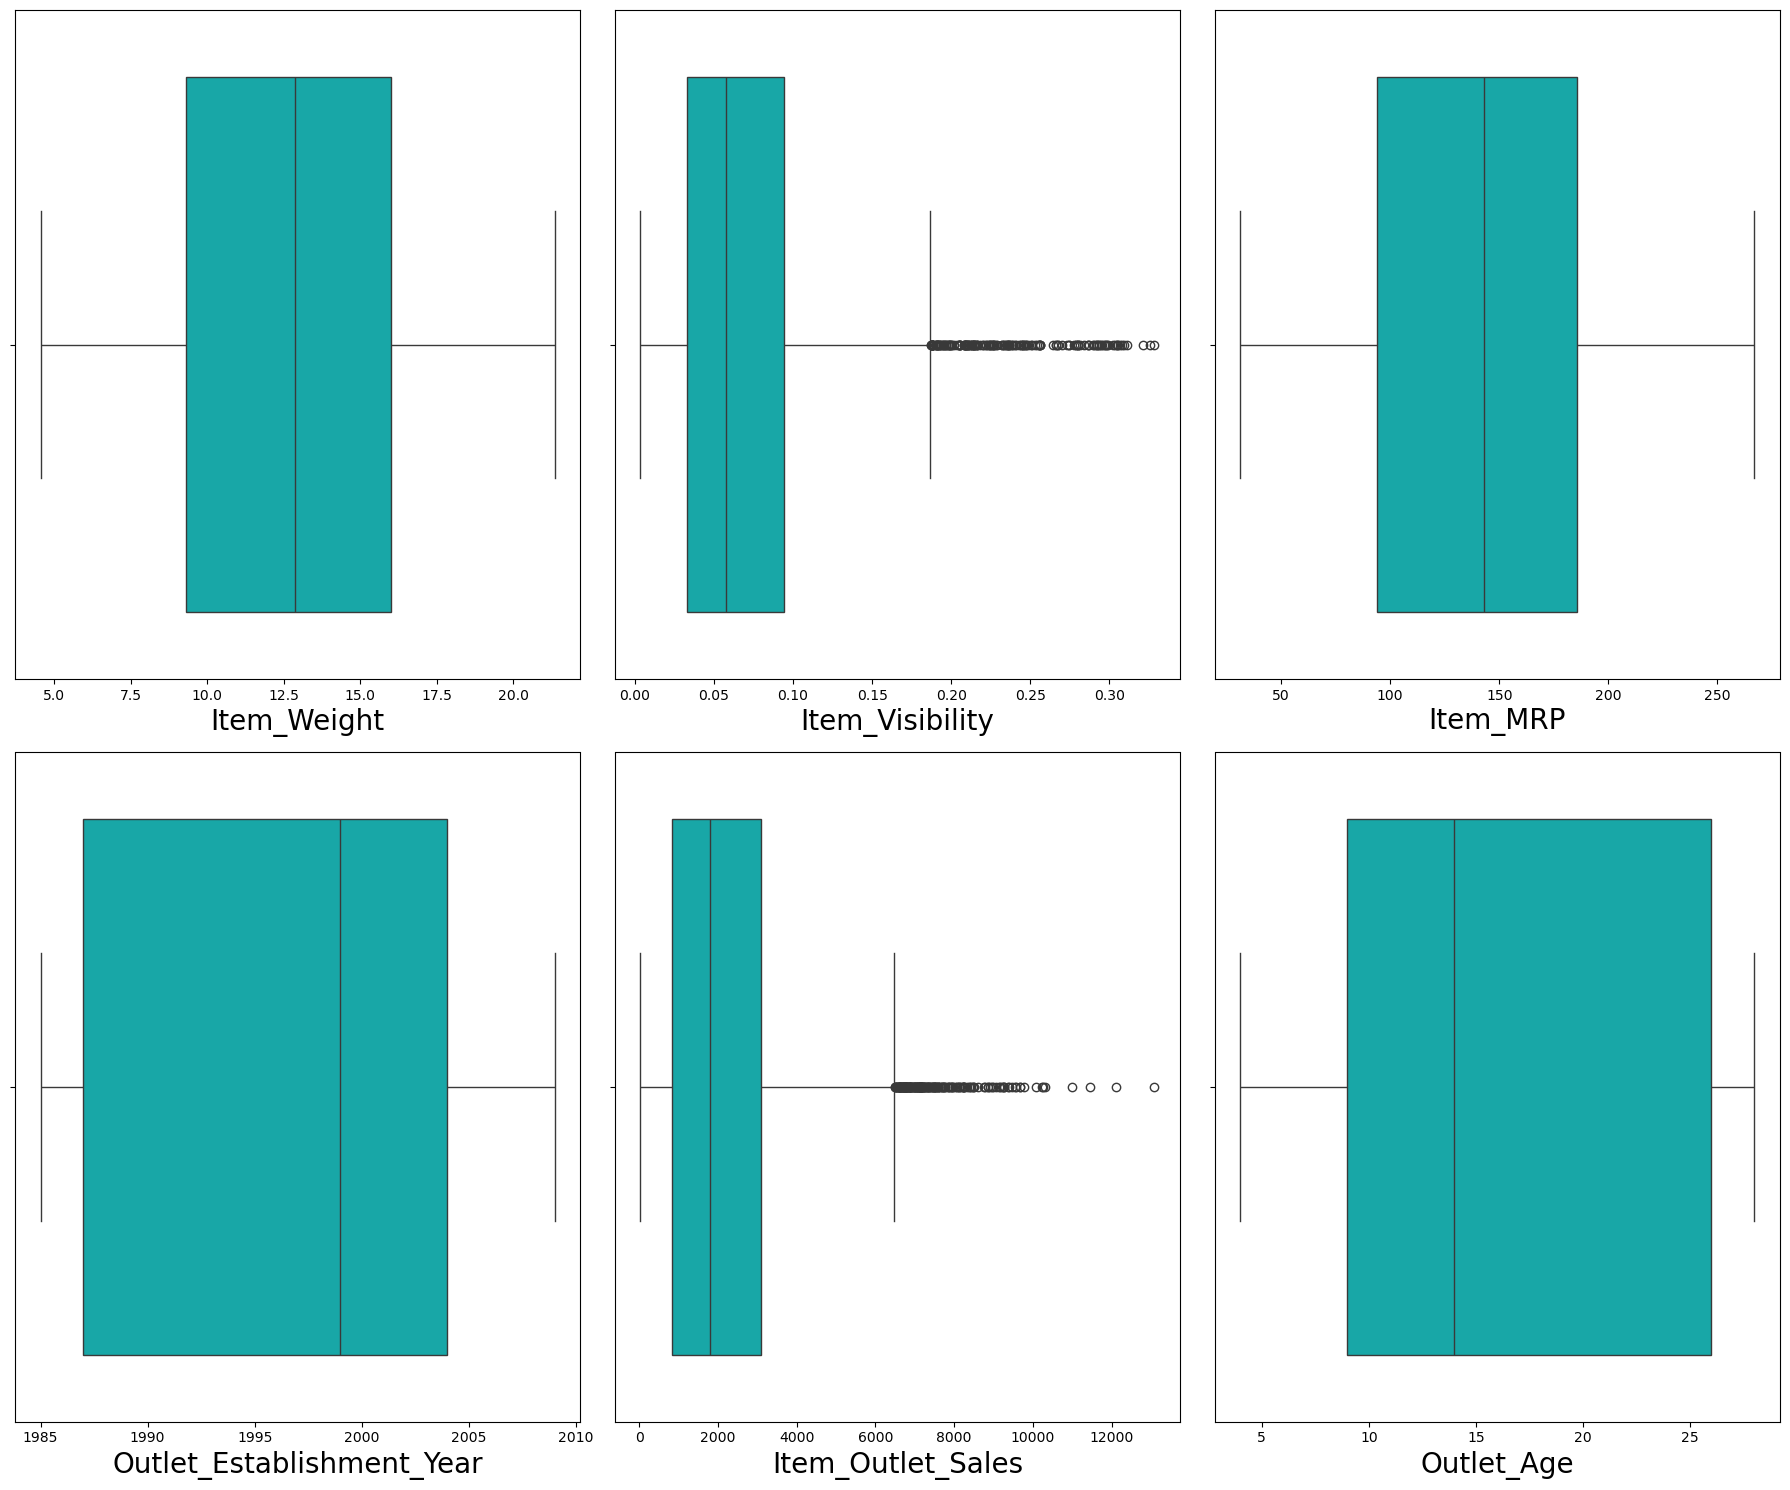

In [53]:
plt.figure(figsize=(18,15), facecolor='white')
plotnumber =1
for column in numerical:
    if plotnumber <=6:
        ax = plt.subplot(2,3,plotnumber)
        sns.boxplot(x=train[column], color='c')
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.tight_layout()
plt.show()

#### Comment-
1. There are outliers in Item visibility and item outlet sales.

#### Box plot for outliers detection in Testing data

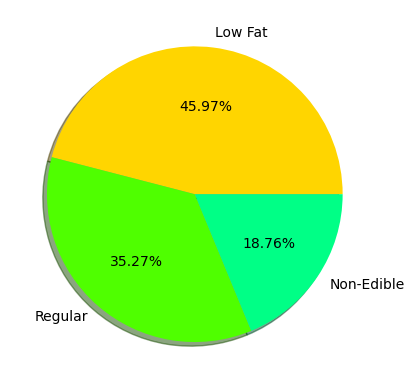

In [61]:
plt.pie(train.Item_Fat_Content.value_counts(),
       labels = train.Item_Fat_Content.value_counts().index,radius =1,
       autopct = '%1.2f%%', shadow=True)
plt.show()

Consumer are buying more Low fat products than Regular fat products. This might be healthy conscious atitude of consumer. 

<Axes: xlabel='Outlet_Location_Type', ylabel='Item_Outlet_Sales'>

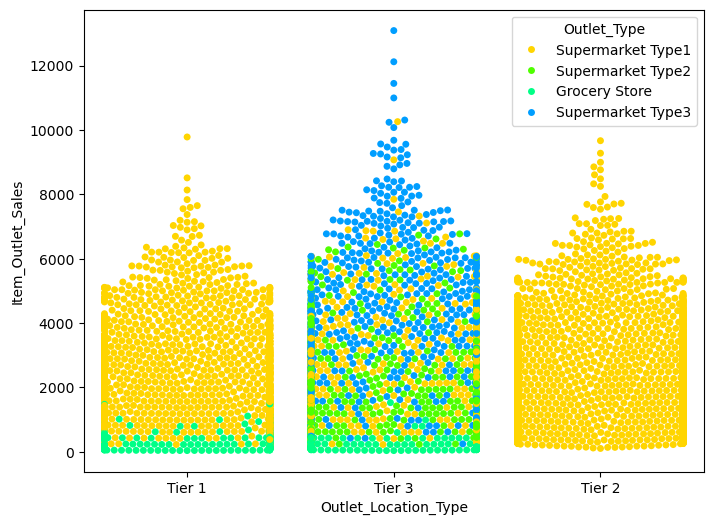

In [59]:
sns.set_palette('hsv')
plt.figure(figsize=(8,6))

sns.swarmplot(data=train, x='Outlet_Location_Type', y='Item_Outlet_Sales', hue='Outlet_Type')

In [60]:
train.pivot_table(values='Item_Outlet_Sales', index='Outlet_Location_Type')

,Item_Outlet_Sales
Outlet_Location_Type,
Tier 1,1876.909159
Tier 2,2323.990559
Tier 3,2279.627651


#### Comment -
1. Tier 3 Cities generate the most revenue and majority of revenue comes from Supermarket Type 2 and Type 3 along with Grocery stores.
2. Tier 2 and Tier 1 cities have more of Supermarket Type1 with a few Grocery stores.

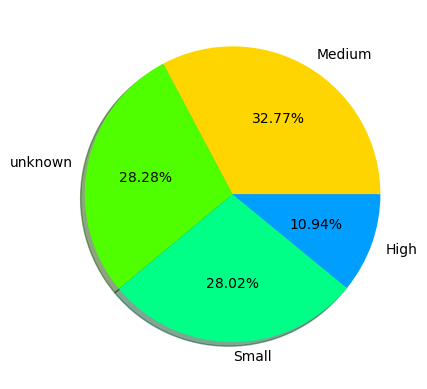

In [62]:
plt.pie(train.Outlet_Size.value_counts(),
       labels = train.Outlet_Size.value_counts().index,radius =1,autopct = '%1.2f%%', shadow=True)

plt.show()

Medium Sized outlets form the majority with 56.29% of total outlets, Small outlets are 32.77% while High sized outlets are 10.94% of the total outlets.

In [ ]:
sns.swarmplot(data=train, x='Outlet_Size', y='Item_Outlet_Sales', hue='Outlet_Type')

#### Comment -
1. Medium Sized Outlets generate the Highest sales and are a mix of Supermaraket Type1,Type2,Type3 and Grocery Stores.
2. High and small Sized Outlets comprise mostly of Supermarket Type1

In [ ]:
plt.figure(figsize=[10,7])
sns.scatterplot(x='Item_Visibility', y='Item_Outlet_Sales',hue='Item_Type',data=train)
plt.title("Sales based on Item Visibility Sorted by Item Type")

In [ ]:
sns.set_palette('gist_rainbow_r')
plt.figure(figsize=[10,7])
sns.scatterplot(x='Item_Visibility', y='Item_Outlet_Sales',hue='Item_Type_Combined',data=train)
plt.title("Sales based on Item Visibility Sorted by Item Type Combined")

#### Comment-
1. Maximum sales comes from Food items.

In [ ]:
sns.set_palette('rainbow')
plt.figure(figsize=[10,7])
sns.scatterplot(x='Item_Visibility', y='Item_MRP',hue='Item_Type_Combined',data=train)
plt.title("Sales based on Item Visibility Sorted by Item Type Combined")

In [ ]:
sns.set_palette('gist_rainbow_r')
plt.figure(figsize=[10,7])
sns.scatterplot(x='Item_Outlet_Sales', y='Item_MRP',hue='Outlet_Type',data=train)
plt.title("Sales based on Item MRP Sorted by outlet Type Combined")

In [ ]:
plt.figure(figsize=(25,8))
sns.barplot(x='Item_Type' ,y='Item_Outlet_Sales', data=train ,palette='gist_rainbow_r')
plt.xlabel('Item_Type', fontsize=14)
plt.show()

In [ ]:
plt.figure(figsize = (14,7))
ax = sns.boxplot(x ='Outlet_Age' ,y='Item_Outlet_Sales',data=train,palette="hsv" )

In [ ]:
sns.set_palette('rainbow')
train.groupby('Outlet_Establishment_Year')['Item_Outlet_Sales'].mean().plot.bar()

In [ ]:
plt.figure(figsize = (10,9))

plt.subplot(411)
ax = sns.boxplot(x ='Item_Type_Combined' ,y='Item_Outlet_Sales',data=train,palette="Set1" )

plt.subplot(412)
ax = sns.boxplot(x ='Item_Fat_Content' ,y='Item_Outlet_Sales',data=train,palette="Set1" )

plt.subplots_adjust(wspace = 0.2, hspace = 0.4,top = 1.5)

plt.show()

#### Lets start looking Outlet_Size, Outlet_Location_Type, and Outlet_Type distribution in Item_Outlet_Sale

In [ ]:
plt.figure(figsize = (10,9))

plt.subplot(311)
sns.boxplot(x='Outlet_Size', y='Item_Outlet_Sales', data=train, palette="Set1")

plt.subplot(312)
sns.boxplot(x='Outlet_Location_Type', y='Item_Outlet_Sales', data=train, palette="Set1")

plt.subplot(313)
sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=train, palette="Set1")

plt.subplots_adjust(wspace = 0.2, hspace = 0.4,top = 1.5)

plt.show()

#### Comment -
1. Tier 1 and Tier 3 locations of Outlet_Location_Type look similar.
2. In the Outlet_Type plot, Grocery Store has most of its data points around the lower sales values as compared to the other categories.

#### Lets now plot Item_Outlet_Sales vs Item Type , Outlet Identifier

In [ ]:
plt.figure(figsize = (14,16))

plt.subplot(411)
ax = sns.boxplot(x='Outlet_Identifier', y='Item_Outlet_Sales', data=train, palette="Set1")
ax.set_title("Outlet_Identifier vs. Item_Outlet_Sales", fontsize=15)
ax.set_xlabel("", fontsize=12)
ax.set_ylabel("Item_Outlet_Sales", fontsize=12)

plt.subplot(412)
ax = sns.boxplot(x='Item_Type', y='Item_Outlet_Sales', data=train, palette="Set1")
ax.set_title("Item_Type vs. Item_Outlet_Sales", fontsize=15)
ax.set_xlabel("", fontsize=12)
ax.set_ylabel("Item_Outlet_Sales", fontsize=12)

plt.subplots_adjust(hspace = 0.9, top = 0.9)
plt.setp(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize = (22,9))
sns.catplot('Outlet_Identifier','Item_Outlet_Sales',kind = 'violin',data = train,aspect = 4)
plt.tight_layout()

In [ ]:
sns.catplot(x = 'Item_Type',y = 'Item_Outlet_Sales',kind = 'violin',data = train,aspect=4)

#### Comment - 
1. The width of a violin plot at a particular level indicates the concentration or density of data at that level. The height of a violin tells us about the range of the target variable values.
2. The distribution for OUT010 and OUT019 categories of Outlet_Identifier are quite similar and very much different from the rest of the categories of Outlet_Identifier.

--------------------------------------------------------------------------------------------------------------------------

# Outliers Detection and Removal In Training data

In [ ]:
from scipy.stats import zscore
z = np.abs(zscore(train))
df1 = train[(z<3).all(axis = 1)]

print ("Shape of the dataframe before removing outliers: ", train.shape)
print ("Shape of the dataframe after removing outliers: ", df1.shape)
print ("Percentage of data loss post outlier removal: ", (train.shape[0]-df1.shape[0])/df.shape[0]*100)

train=df1.copy() # reassigning the changed dataframe name to our original dataframe name

In [ ]:
df_train_new =df_train[~((df_train <(Q1 - 1.5*IQR)) | (df_train >(Q3 + 1.5*IQR))).any(axis=1)]
print(df_train_new.shape)

In [ ]:
train.shape

##### Data Loss

In [ ]:
print("\033[1m"+'Percentage Data Loss :'+"\033[0m",((8523-8164)/8523)*100,'%')

----------------------------------------------------------------------------------------------------------------------------

# Outliers Detection and Removal In Testing data

In [ ]:
df_test =test.copy()
Q1 =df_test.quantile(0.25)
Q3= df_test.quantile(0.75)
IQR = Q3-Q1
print(IQR)

In [ ]:
df_test_new =df_test[~((df_test <(Q1 - 1.5*IQR)) | (df_test >(Q3 + 1.5*IQR))).any(axis=1)]
print(df_test_new.shape)

In [ ]:
test.shape

##### Data Loss

In [ ]:
print("\033[1m"+'Percentage Data Loss :'+"\033[0m",((5681-5547)/5681)*100,'%')

---------------------------------------------------------------------------------------------------------------------------

# Multicollinearity, Label Encoding, Correlation and Skewness Handling in Train Data

### 1. Skewness of features

In [ ]:
df_train_new.skew()

#### Comment -
1. Optimal range for skewness is -0.5 to 0.5.
2. Item_Visibility and Item_Outlet_Sales are Skewed in nature, need to transform.

#### Transforming positive or right skew data using boxcox transformation

In [ ]:
from scipy.stats import boxcox

In [ ]:
df_train_new['Item_Visibility']=boxcox(df_train_new['Item_Visibility'],0.5)

In [ ]:
df_train_new['Item_Outlet_Sales']=boxcox(df_train_new['Item_Outlet_Sales'],0.5)

In [ ]:
df_train_new.skew()

### 2. Corrleation 

In [ ]:
df_train_new.corr()

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df_train_new.corr(),annot=True,  cmap='gist_earth')

In [ ]:
plt.figure(figsize = (12,5))
df_train_new.corr()['Item_Outlet_Sales'].drop(['Item_Outlet_Sales']).plot(kind='bar',color = 'c')
plt.xlabel('Features',fontsize=15)
plt.ylabel('Item_Outlet_Sales',fontsize=15)
plt.title('Correlation of features with class',fontsize = 18)
plt.show()

### 3. Checking Multicollinearity between features using variance_inflation_factor

In [ ]:
df2=df_train_new.drop(columns=['Item_Identifier','Item_Fat_Content','Item_Type','Outlet_Identifier','Outlet_Size','Outlet_Location_Type','Outlet_Type','Item_Type_Combined'])

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif= pd.DataFrame()
vif['VIF']= [variance_inflation_factor(df2.values,i) for i in range(df2.shape[1])]
vif['Features']= df2.columns
vif

In [ ]:
df3=df2.drop(columns=['Outlet_Establishment_Year'])

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif= pd.DataFrame()
vif['VIF']= [variance_inflation_factor(df3.values,i) for i in range(df3.shape[1])]
vif['Features']= df3.columns
vif

### 4. Label Encoding on Train Data

In [ ]:
df_train_new['Item_Fat_Content']=df_train_new['Item_Fat_Content'].astype('category')
df_train_new['Item_Type']=df_train_new['Item_Type'].astype('category')
df_train_new['Outlet_Identifier']=df_train_new['Outlet_Identifier'].astype('category')
df_train_new['Outlet_Size']=df_train_new['Outlet_Size'].astype('category')
df_train_new['Outlet_Location_Type']=df_train_new['Outlet_Location_Type'].astype('category')
df_train_new['Outlet_Type']=df_train_new['Outlet_Type'].astype('category')
df_train_new['Item_Type_Combined']=df_train_new['Item_Type_Combined'].astype('category')

In [ ]:
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()

In [ ]:
df_train_new['Item_Fat_Content']=labelencoder.fit_transform(df_train_new['Item_Fat_Content'])
df_train_new['Item_Type']=labelencoder.fit_transform(df_train_new['Item_Type'])
df_train_new['Outlet_Identifier']=labelencoder.fit_transform(df_train_new['Outlet_Identifier'])
df_train_new['Outlet_Size']=labelencoder.fit_transform(df_train_new['Outlet_Size'])
df_train_new['Outlet_Location_Type']=labelencoder.fit_transform(df_train_new['Outlet_Location_Type'])
df_train_new['Outlet_Type']=labelencoder.fit_transform(df_train_new['Outlet_Type'])
df_train_new['Item_Type_Combined']=labelencoder.fit_transform(df_train_new['Item_Type_Combined'])

In [ ]:
# droping item Identifier and Outlet_Establishment_Year as we created alternate columns for them.
df_train_new=df_train_new.drop(columns=['Outlet_Establishment_Year','Item_Identifier'])

In [ ]:
df_train_new.shape

#### 4.1. variance_inflation_factor after label encoding

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif= pd.DataFrame()
vif['VIF']= [variance_inflation_factor(df_train_new.values,i) for i in range(df_train_new.shape[1])]
vif['Features']= df_train_new.columns
vif

#### 4.2. Heamap of correlation after label encoding

In [ ]:
plt.figure(figsize=(14,12))
sns.heatmap(df_train_new.corr(),annot=True,  cmap='gist_earth')

In [ ]:
plt.figure(figsize = (12,5))
df_train_new.corr()['Item_Outlet_Sales'].drop(['Item_Outlet_Sales']).plot(kind='bar',color = 'c')
plt.xlabel('Features',fontsize=15)
plt.ylabel('Item_Outlet_Sales',fontsize=15)
plt.title('Correlation of features with class',fontsize = 18)
plt.show()

----------------------------------------------------------------------------------------------------------------------------

# Multicollinearity, Label Encoding, Correlation and Skewness Handling in Test Data

### 1. Skewness of features

In [ ]:
df_test_new.skew()

#### Transforming positive or right skew data using boxcox transformation

In [ ]:
from scipy.stats import boxcox

In [ ]:
df_test_new['Item_Visibility']=boxcox(df_test_new['Item_Visibility'],0.5)

In [ ]:
df_test_new.skew()

### 2. Correlation

In [ ]:
df_test_new.corr()

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df_test_new.corr(),annot=True,  cmap='gist_earth')

### 3. Checking Multicollinearity between features using variance_inflation_factor

In [ ]:
df4=df_test_new.drop(columns=['Item_Identifier','Item_Fat_Content','Item_Type','Outlet_Identifier','Outlet_Size','Outlet_Location_Type','Outlet_Type','Item_Type_Combined'])

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif= pd.DataFrame()
vif['VIF']= [variance_inflation_factor(df4.values,i) for i in range(df4.shape[1])]
vif['Features']= df4.columns
vif

### 4. Label Encoding on Test Data

In [ ]:
df_test_new['Item_Fat_Content']=df_test_new['Item_Fat_Content'].astype('category')
df_test_new['Item_Type']=df_test_new['Item_Type'].astype('category')
df_test_new['Outlet_Identifier']=df_test_new['Outlet_Identifier'].astype('category')
df_test_new['Outlet_Size']=df_test_new['Outlet_Size'].astype('category')
df_test_new['Outlet_Location_Type']=df_test_new['Outlet_Location_Type'].astype('category')
df_test_new['Outlet_Type']=df_test_new['Outlet_Type'].astype('category')
df_test_new['Item_Type_Combined']=df_test_new['Item_Type_Combined'].astype('category')

In [ ]:
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()

In [ ]:
df_test_new['Item_Fat_Content']=labelencoder.fit_transform(df_test_new['Item_Fat_Content'])
df_test_new['Item_Type']=labelencoder.fit_transform(df_test_new['Item_Type'])
df_test_new['Outlet_Identifier']=labelencoder.fit_transform(df_test_new['Outlet_Identifier'])
df_test_new['Outlet_Size']=labelencoder.fit_transform(df_test_new['Outlet_Size'])
df_test_new['Outlet_Location_Type']=labelencoder.fit_transform(df_test_new['Outlet_Location_Type'])
df_test_new['Outlet_Type']=labelencoder.fit_transform(df_test_new['Outlet_Type'])
df_test_new['Item_Type_Combined']=labelencoder.fit_transform(df_test_new['Item_Type_Combined'])

In [ ]:
# droping item Identifier and Outlet_Establishment_Year as we created alternate columns for them.
df_test_new=df_test_new.drop(columns=['Outlet_Establishment_Year','Item_Identifier'])

In [ ]:
df_test_new.shape

# Standard Scaling

### 1. Standard Scaling of Train Data

In [ ]:
X=df_train_new.drop(columns =['Item_Outlet_Sales'])
Y=df_train_new['Item_Outlet_Sales']

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_scale_train = scaler.fit_transform(X)

In [ ]:
X_scale_train

### 2. Standard Scaling of Test Data

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_scale_test = scaler.fit_transform(df_test_new)

In [ ]:
X_scale_test

# Machine Learning Model Building

In [ ]:
from sklearn.linear_model import LinearRegression
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.svm import SVR
# from sklearn.ensemble import AdaBoostRegressor
# from sklearn.ensemble import  GradientBoostingRegressor
# from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
# from sklearn.linear_model import  Ridge
# from sklearn.linear_model import  Lasso
# from xgboost import XGBRegressor

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scale_train, Y, random_state=42, test_size=.33)
print('Training feature matrix size:',X_train.shape)
print('Training target vector size:',Y_train.shape)
print('Test feature matrix size:',X_test.shape)
print('Test target vector size:',Y_test.shape)

####  Finding Best Random state

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
maxR2_score=0
maxRS=0
for i in range(1,250):
    X_train, X_test, Y_train, Y_test = train_test_split(X_scale_train, Y, random_state=i, test_size=.33)
    lin_reg=LinearRegression()
    lin_reg.fit(X_train,Y_train)
    y_pred=lin_reg.predict(X_test)
    R2=r2_score(Y_test,y_pred)
    if R2>maxR2_score:
        maxR2_score=R2
        maxRS=i
print('Best R2 Score is', maxR2_score ,'on Random_state', maxRS)

## Linear Regression : Base model

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scale_train, Y, random_state=16, test_size=.33)
lin_reg=LinearRegression()
lin_reg.fit(X_train,Y_train)
lin_reg.score(X_train,Y_train)
y_pred=lin_reg.predict(X_test)
print('\033[1m'+'Predicted sales:'+'\033[0m\n',y_pred)
print('\n')
print('\033[1m'+'Actual sales:'+'\033[0m\n',Y_test)

### Linear Regression Evaluation Matrix

In [ ]:
print('\033[1m'+' Error :'+'\033[0m')
print('Mean absolute error :', mean_absolute_error(Y_test,y_pred))
print('Mean squared error :', mean_squared_error(Y_test,y_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(Y_test,y_pred)))
print('\n')
from sklearn.metrics import r2_score
print('\033[1m'+' R2 Score :'+'\033[0m')
print(r2_score(Y_test,y_pred))

In [ ]:
plt.figure(figsize=(10,8))
y_pred=lin_reg.predict(X_test)
sns.scatterplot(Y_test.round(2), y_pred, cmap='hsv')
print('\033[1m'+' True Values Vs Predicted Value plot :' +'\033[0m')
plt.xlabel('True Values' , fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.tight_layout()

## Finding n_neighbors for KNN Regressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn import neighbors
from math import sqrt
from sklearn.metrics import mean_squared_error
rmse_val = [] #to store rmse values for different k
for K in range(40):
    K = K+1
    model = neighbors.KNeighborsRegressor(n_neighbors = K)

    model.fit(X_train,Y_train)  #fit the model
    y_pred=model.predict(X_test) #make prediction on test set
    error = sqrt(mean_squared_error(Y_test,y_pred)) #calculate rmse
    rmse_val.append(error) #store rmse values
    print('RMSE value for k= ' , K , 'is:', error)

In [ ]:
#plotting the rmse values against k values -
plt.figure(figsize = (8,6))
plt.plot(range(40), rmse_val, color='blue', linestyle='dashed', marker='o', markerfacecolor='green', markersize=10)

#### Comment- 
At k= 16, we get the minimum RMSE value which approximately 21.513403074734452, and shoots up on further increasing the k value. We can safely say that k=20 will give us the best result in this case

---------------------------------------------------------------------------------------------------------------------------

## Applying other Regression Model

In [ ]:
rf = RandomForestRegressor(n_estimators = 100 )
svr=SVR()
dtc = DecisionTreeRegressor()
adb=AdaBoostRegressor()
gradb=GradientBoostingRegressor()
knn=KNeighborsRegressor(n_neighbors=16)
xgb=XGBRegressor()
model = [rf,svr,dtc,adb,gradb,knn,xgb]

for m in model:
    m.fit(X_train,Y_train)
    m.score(X_train,Y_train)
    y_pred = m.predict(X_test)
    print('\n')                                        
    print('\033[1m'+' Error of ', m, ':' +'\033[0m')
    print('Mean absolute error :', mean_absolute_error(Y_test,y_pred))
    print('Mean squared error :', mean_squared_error(Y_test,y_pred))
    print('Root Mean Squared Error:', np.sqrt(mean_squared_error(Y_test,y_pred)))
    print('\n')

    print('\033[1m'+' R2 Score :'+'\033[0m')
    print(r2_score(Y_test,y_pred)) 
    print('\n')
    print('==============================================================================================================')

#### Here we can see that GradientBoostingRegressor() algorithm gives maximum R2 score : 0.6827636313072999 with Minimum Root Mean Squared Error: 19.756825093870162

In [ ]:
rf = RandomForestRegressor(n_estimators = 100 )
svr=SVR()
dtc = DecisionTreeRegressor()
adb=AdaBoostRegressor()
gradb=GradientBoostingRegressor()
knn=KNeighborsRegressor(n_neighbors=15)
model = [rf,svr,dtc,adb,gradb,knn,xgb]

for m in model:
    plt.figure(figsize=(12,7))
    m.fit(X_train,Y_train)
    y_pred=m.predict(X_test)
    print('\n')
    print('\033[1m'+' True Values Vs Predicted Value plot', m, ':' +'\033[0m')
    sns.scatterplot(Y_test.round(2), y_pred)
    plt.xlabel('True Values' , fontsize=15)
    plt.ylabel('Predictions', fontsize=15)
    plt.tight_layout()
    plt.show()
    print('\n')
    print('===================================================================================================')

# Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score
model = [lin_reg,rf,svr,dtc,adb,gradb,knn,xgb]
for m in model:
    score = cross_val_score(m, X, Y, cv =4)
    print('\n')
    print('\033[1m'+'Cross Validation Score :',m,":"+'\033[0m\n')
    print("Score :" ,score)
    print("Mean Score :",score.mean())
    print("Std deviation :",score.std())
    print('\n')
    print('\033[1m'+' R2 Score :'+'\033[0m')
    print(r2_score(Y_test,y_pred))
    print('\n')
    print('==============================================================================================================')

#### From above cross validattion, we can see that Gradient Boosting Regressor() gives us maximum  R2 score(0.6238449573040779)  and with maximum mean score of 0.6504855259743363. So we will apply Hyperparameter tuning on Gradient Boosting Regressor

# Hyper Parameter Tuning : GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
parameters = [{   'learning_rate': [0.01,0.03,0.04],
                  'subsample'    : [0.5, 0.3, 0.1],
                  'n_estimators' : [250,500,750],
                  'max_depth'    : [6,8,10]}] 

In [ ]:
GCV = GridSearchCV(GradientBoostingRegressor(),parameters,cv=3,n_jobs = -1, verbose=3)
GCV.fit(X_train,Y_train)

In [ ]:
GCV.best_params_

# Final Model

In [ ]:
Final_mod = GradientBoostingRegressor(learning_rate=0.01 ,n_estimators= 250, max_depth=6 ,subsample=0.5)
Final_mod.fit(X_train,Y_train)
y_pred=Final_mod.predict(X_test)
print('\n')                                        
print('\033[1m'+' Error in Final Model :' +'\033[0m')
print('Mean absolute error :', mean_absolute_error(Y_test,y_pred))
print('Mean squared error :', mean_squared_error(Y_test,y_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(Y_test,y_pred)))
print('\n')
print('\033[1m'+' R2 Score of Final Model :'+'\033[0m')
print(r2_score(Y_test,y_pred)) 
print('\n')

In [ ]:
plt.figure(figsize=(12,7))
y_pred=Final_mod.predict(X_test)
sns.scatterplot(Y_test.round(2), y_pred)
print('\033[1m'+' True Values Vs Predicted Value plot :' +'\033[0m')
plt.xlabel('True Values' , fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.tight_layout()

In [ ]:
feat_importances = pd.Series(Final_mod.feature_importances_, index=X.columns)
feat_importances = feat_importances.nlargest()
feat_importances.plot(kind='barh')

## Saving model

In [ ]:
import joblib
joblib.dump(Final_mod,'Big_Data_Mart_Sales_Final.pkl')

## Predication on Test data

In [ ]:
y_pred=Final_mod.predict(X_scale_test)

In [ ]:
y_pred 